# Santander Customer Transaction Prediction

**Course:** Machine Learning II — IE University Madrid

**Author:** Elad Moshe

**Program:** MCSBT

**Date:** May 2026


## Overview

Binary classification task: predict which Santander customers will make a specific transaction in he future. The dataset contains 200 anonymised numerical features (`var_0` – `var_199`) and a heavily mbalanced target (~10% positive class).

Evaluation metric: **AUC-ROC**.

## Objective To Beat

Competition total: ~8,802 teams


| Objective | Rank target | AUC-ROC To Beat |
|--------|-------|-------| 
| Mandatory (Naive Bayes) |	Top 10% = top ~880 |	~0.899+ |
| Optional (LightGBM) |	Top 60 = top 0.7% |	~0.921+  |

## Notebook Structure

1. Data Loading & Exploration
2. Feature Analysis
3. Preprocessing & Feature Augmentation
4. Part 1 — Naive Bayes
5. Detection of Synthetic Test Data
6. Advanced Feature Engineering
7. Improved Naive Bayes with Value-Count Features
8. Part 2 — LightGBM
9. Hyperparameter Tuning
10. Feature Importance
11. Submissions

> **AI Usage Disclaimer:** This notebook was developed with AI assistance (Claude, Anthropic). AI was used to improve documentation and markdown explanations, support the EDA process (structuring the analysis, writing visualisation code), and to iterate on and improve results after initial trials — including debugging, refining the preprocessing pipeline, and evaluating modelling choices. Additionally, ideas and approaches from public Kaggle submissions for this competition were reviewed and selectively incorporated to explore different feature engineering and ensemble strategies. All final modelling decisions and result interpretation are the author's own.

In [1]:
%pip install numpy pandas matplotlib seaborn scipy scikit-learn lightgbm optuna --quiet

Note: you may need to restart the kernel to use updated packages.


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

import lightgbm as lgb
import optuna
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

SEED = 42
N_FOLDS = 5
DATA_PATH = 'data/'

---
## 1. Data Loading & Exploration

In [16]:
df_train = pd.read_csv(DATA_PATH + 'train.csv')
df_test  = pd.read_csv(DATA_PATH + 'test.csv')

print('Train shape:', df_train.shape)
print('Test shape :', df_test.shape)
df_train.head(3)

Train shape: (200000, 202)
Test shape : (200000, 201)


,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9,var_10,var_11,var_12,var_13,var_14,var_15,var_16,var_17,var_18,var_19,var_20,var_21,var_22,...,var_175,var_176,var_177,var_178,var_179,var_180,var_181,var_182,var_183,var_184,var_185,var_186,var_187,var_188,var_189,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,-4.9200,5.7470,2.9252,3.1821,14.0137,0.5745,8.7989,14.5691,5.7487,-7.2393,4.2840,30.7133,10.5350,16.2191,2.5791,...,7.7423,-10.1245,13.7241,-3.5189,1.7202,-8.4051,9.0164,3.0657,14.3691,25.8398,5.8764,11.8411,-19.7159,17.5743,0.5857,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,3.1468,8.0851,-0.4032,8.0585,14.0239,8.4135,5.4345,13.7003,13.8275,-15.5849,7.8000,28.5708,3.4287,2.7407,8.5524,...,10.4968,-7.2352,16.5721,-7.3477,11.0752,-5.5937,9.4878,-14.9100,9.4245,22.5441,-4.8622,7.6543,-15.9319,13.3175,-0.3566,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,-4.9193,5.9525,-0.3249,-11.2648,14.1929,7.3124,7.5244,14.6472,7.6782,-1.7395,4.7011,20.4775,17.7559,18.1377,1.2145,...,10.9202,-0.3104,8.8438,-9.7009,2.4013,-4.2935,9.3908,-13.2648,3.1545,23.0866,-5.3000,5.3745,-6.2660,10.1934,-0.8417,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965


In [17]:
# Data types and missing values
print(df_train.dtypes.value_counts())
print('\nMissing values in train:', df_train.isnull().sum().sum())
print('Missing values in test :', df_test.isnull().sum().sum())

float64    200
str          1
int64        1
Name: count, dtype: int64

Missing values in train: 0
Missing values in test : 0


target
0    179902
1     20098
Name: count, dtype: int64

Positive rate: 10.05%


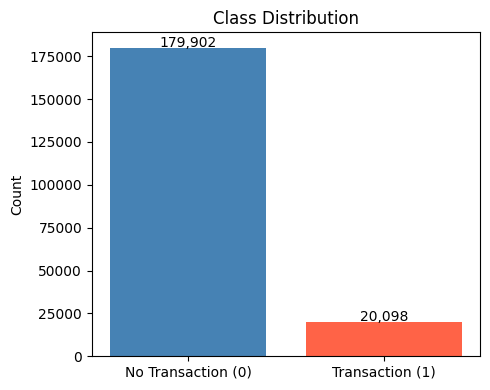

In [5]:
# Target distribution
target_counts = df_train['target'].value_counts()
print(target_counts)
print(f'\nPositive rate: {target_counts[1] / len(df_train):.2%}')

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['No Transaction (0)', 'Transaction (1)'], target_counts.values, color=['steelblue', 'tomato'])
ax.set_title('Class Distribution')
ax.set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    ax.text(i, v + 500, f'{v:,}', ha='center')
plt.tight_layout()
plt.show()

#heavily imbalanced dataset

---
## 2. Feature Analysis

Check whether individual features look Gaussian per class — the core assumption of GaussianNB.

Number of features: 200


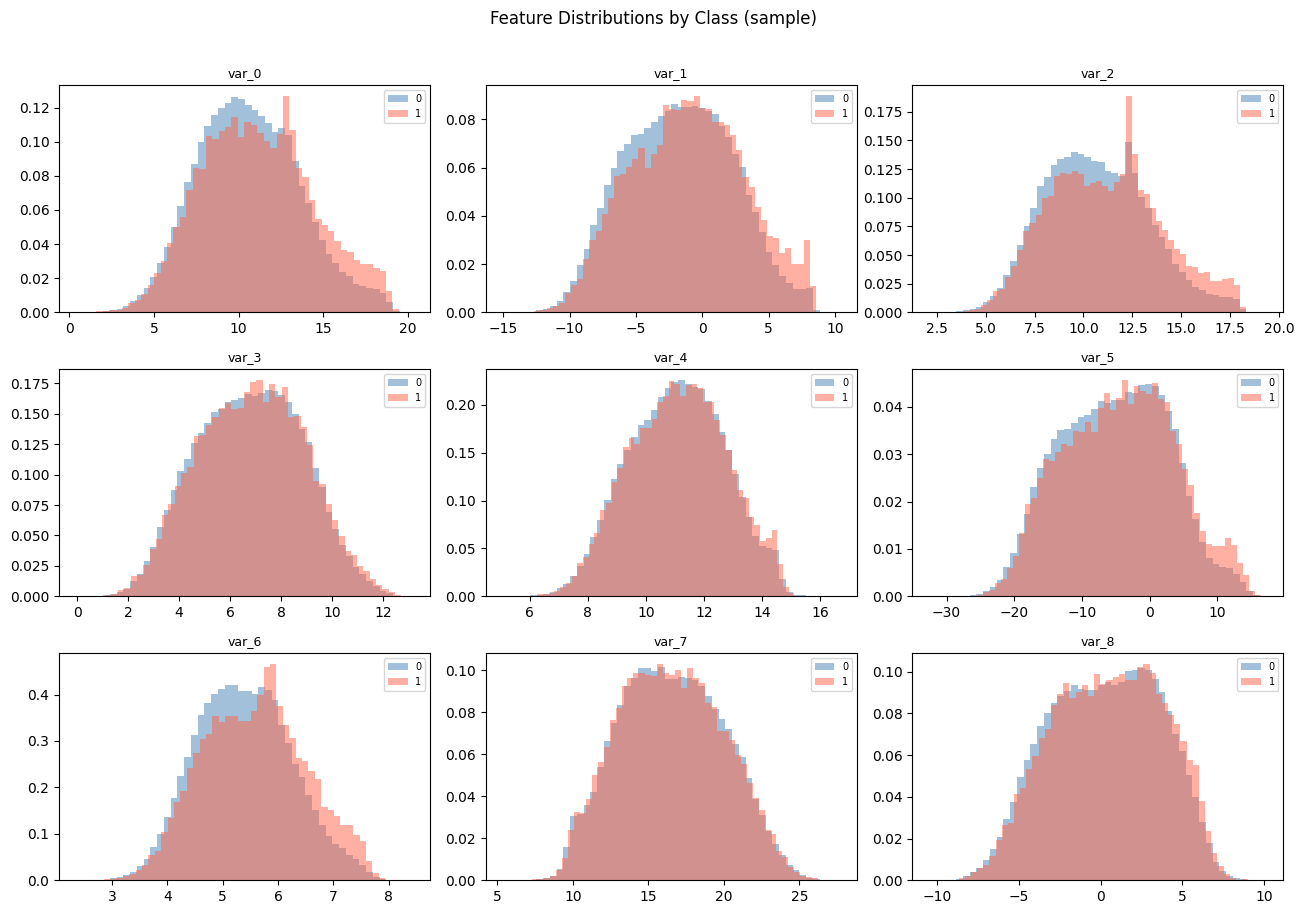

In [18]:
features = [c for c in df_train.columns if c.startswith('var_')]
print(f'Number of features: {len(features)}')

# Plot distributions for a sample of features split by class
sample_features = features[:9]
fig, axes = plt.subplots(3, 3, figsize=(13, 9))
axes = axes.flatten()

for i, feat in enumerate(sample_features):
    for label, color in [(0, 'steelblue'), (1, 'tomato')]:
        axes[i].hist(df_train.loc[df_train['target'] == label, feat],
                     bins=50, alpha=0.5, color=color, density=True, label=str(label))
    axes[i].set_title(feat, fontsize=9)
    axes[i].legend(fontsize=7)

plt.suptitle('Feature Distributions by Class (sample)', y=1.01)
plt.tight_layout()
plt.show()

In [19]:
# Per-class mean difference — features with large separation are most discriminative
class0 = df_train[df_train['target'] == 0][features]
class1 = df_train[df_train['target'] == 1][features]

mean_diff = (class1.mean() - class0.mean()).abs().sort_values(ascending=False)
print('Top 10 features by |mean difference| between classes:')
print(mean_diff.head(10))

Top 10 features by |mean difference| between classes:
var_139   1.8939
var_76    1.6349
var_149   1.6345
var_21    1.5944
var_184   1.4975
var_174   1.4638
var_45    1.4285
var_80    1.4250
var_40    1.3639
var_90    1.2860
dtype: float64


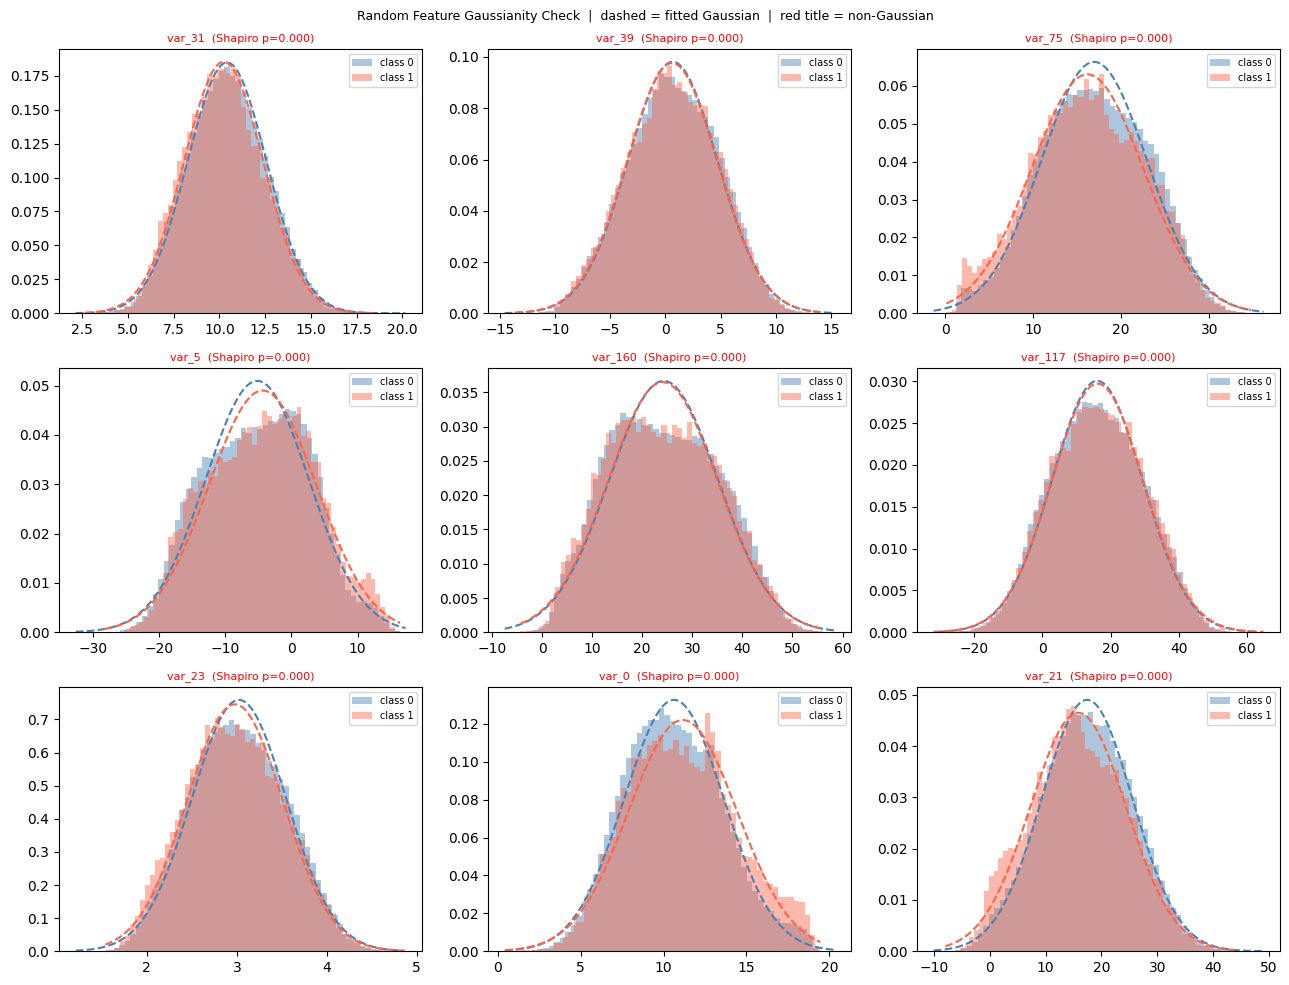

In [8]:
# Re-run this cell to inspect 9 new random features each time
rng = np.random.default_rng()  # unseeded — different every run
sample_feats = rng.choice(features, size=9, replace=False).tolist()

fig, axes = plt.subplots(3, 3, figsize=(13, 10))
axes = axes.flatten()

for i, feat in enumerate(sample_feats):
    ax = axes[i]
    for label, color in [(0, 'steelblue'), (1, 'tomato')]:
        vals = df_train.loc[df_train['target'] == label, feat]
        ax.hist(vals, bins=60, alpha=0.45, color=color, density=True, label=f'class {label}')
        # overlay fitted Gaussian
        mu, sigma = vals.mean(), vals.std()
        x = np.linspace(vals.min(), vals.max(), 200)
        ax.plot(x, stats.norm.pdf(x, mu, sigma), color=color, linewidth=1.5, linestyle='--')

    # Shapiro-Wilk on a sample (max 5000 obs) — p-value printed as guide
    sample = df_train[feat].sample(min(5000, len(df_train)), random_state=0)
    _, p = stats.shapiro(sample)
    ax.set_title(f'{feat}  (Shapiro p={p:.3f})', fontsize=8,
                 color='green' if p > 0.05 else 'red')
    ax.legend(fontsize=7)

plt.suptitle('Random Feature Gaussianity Check  |  dashed = fitted Gaussian  |  red title = non-Gaussian', fontsize=9)
plt.tight_layout()
plt.show()

---
## 3. Preprocessing & Feature Augmentation

The data is already clean. We add **row-wise statistical aggregates** as extra features as suggested in the hints.

In [20]:
def add_rowwise_features(df, features):
    """Add row-wise statistical aggregates across the 200 var_ features."""
    df = df.copy()
    vals = df[features]
    df['row_mean'] = vals.mean(axis=1)
    df['row_std']  = vals.std(axis=1)
    df['row_min']  = vals.min(axis=1)
    df['row_max']  = vals.max(axis=1)
    df['row_sum']  = vals.sum(axis=1)
    df['row_skew'] = vals.skew(axis=1)
    df['row_kurt'] = vals.kurt(axis=1)
    return df

df_train_nb = add_rowwise_features(df_train, features)
df_test_nb  = add_rowwise_features(df_test,  features)

extra_features = ['row_mean', 'row_std', 'row_min', 'row_max', 'row_sum', 'row_skew', 'row_kurt']
nb_features = features + extra_features

X_train_nb = df_train_nb[nb_features].values
y_train    = df_train_nb['target'].values
X_test_nb  = df_test_nb[nb_features].values

print('Feature matrix shape (train):', X_train_nb.shape)

Feature matrix shape (train): (200000, 207)


---
## 4. Part 1 — Naive Bayes

### 4.1 Model Training

In [21]:
gnb = GaussianNB(var_smoothing=1e-9)  # var_smoothing to be tuned
gnb.fit(X_train_nb, y_train)
print('GaussianNB trained.')

GaussianNB trained.


### 4.2 Cross-Validation

In [22]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

cv_scores = cross_val_score(
    GaussianNB(var_smoothing=1e-9),
    X_train_nb, y_train,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1
)

baseline_auc = cv_scores.mean()
print(f'AUC per fold: {cv_scores.round(4)}')
print(f'Mean AUC : {baseline_auc:.4f}')
print(f'Std  AUC : {cv_scores.std():.4f}')

AUC per fold: [0.8861 0.8854 0.8785 0.8828 0.8853]
Mean AUC : 0.8836
Std  AUC : 0.0028


In [23]:
# var_smoothing grid search
smoothing_values = np.logspace(-12, -1, 12)
results = []

for vs in smoothing_values:
    scores = cross_val_score(
        GaussianNB(var_smoothing=vs),
        X_train_nb, y_train,
        cv=skf, scoring='roc_auc', n_jobs=-1
    )
    results.append({'var_smoothing': vs, 'mean_auc': scores.mean(), 'std_auc': scores.std()})

results_df = pd.DataFrame(results).sort_values('mean_auc', ascending=False)
print(results_df.to_string(index=False))

best_vs  = results_df.iloc[0]['var_smoothing']
best_auc = results_df.iloc[0]['mean_auc']

print(f'\nBaseline AUC (var_smoothing=1e-9)        : {baseline_auc:.4f}')
print(f'Best     AUC (var_smoothing={best_vs:.2e}) : {best_auc:.4f}')
print(f'Improvement                                : {best_auc - baseline_auc:+.4f}')

 var_smoothing  mean_auc  std_auc
        0.0000    0.8836   0.0028
        0.0000    0.8836   0.0028
        0.0000    0.8836   0.0028
        0.0000    0.8836   0.0028
        0.0000    0.8836   0.0028
        0.0000    0.8835   0.0028
        0.0000    0.8832   0.0028
        0.0000    0.8797   0.0026
        0.0001    0.8696   0.0028
        0.0010    0.8497   0.0034
        0.0100    0.8016   0.0041
        0.1000    0.7266   0.0048

Baseline AUC (var_smoothing=1e-9)        : 0.8836
Best     AUC (var_smoothing=1.00e-12) : 0.8836
Improvement                                : +0.0000


In [25]:
# Retrain with best smoothing
gnb_best = GaussianNB(var_smoothing=best_vs)
gnb_best.fit(X_train_nb, y_train)
print('Final GaussianNB retrained.')

Final GaussianNB retrained.


### 4.3 Prediction & Submission

In [14]:
nb_probs = gnb_best.predict_proba(X_test_nb)[:, 1]

submission_nb = pd.DataFrame({
    'ID_code': df_test['ID_code'],
    'target': nb_probs
})
submission_nb.to_csv('submission_naive_bayes.csv', index=False)
print('Saved: submission_naive_bayes.csv')
submission_nb.head()

Saved: submission_naive_bayes.csv


,ID_code,target
0,test_0,0.1008
1,test_1,0.1602
2,test_2,0.1884
3,test_3,0.1303
4,test_4,0.0326


---
## 5. Detection of Synthetic Test Data

The test set (~200k rows) is known to contain ~100k **synthetic** records generated by re-sampling feature values.  
We identify real rows by finding rows that contain at least one value which appears **exactly once** across the entire test set for that feature (a "unique signature").

In [26]:
# Step 1: for each feature, find values that appear exactly once in the test set
# A row is REAL if it has at least one such unique value

is_real = pd.Series(False, index=df_test.index)

for col in features:
    value_counts = df_test[col].value_counts()
    unique_vals   = set(value_counts[value_counts == 1].index)
    is_real |= df_test[col].isin(unique_vals)

df_test_real      = df_test[is_real].reset_index(drop=True)
df_test_synthetic = df_test[~is_real].reset_index(drop=True)

print(f'Real test rows     : {len(df_test_real):,}')
print(f'Synthetic test rows: {len(df_test_synthetic):,}')
print(f'Total              : {len(df_test):,}')

Real test rows     : 100,000
Synthetic test rows: 100,000
Total              : 200,000


In [27]:
# Step 2 (optional verification): show that synthetic rows are "Frankenstein" records
# by counting distinct real donors for a sample synthetic row

real_vals = {col: set(df_test_real[col].values) for col in features[:20]}  # subset for speed

sample_synth = df_test_synthetic.iloc[0]
donors_per_feature = {}
for col in features[:20]:
    matches = df_test_real[df_test_real[col] == sample_synth[col]]
    if len(matches) == 1:
        donors_per_feature[col] = matches.index[0]

unique_donors = len(set(donors_per_feature.values()))
print(f'Unique real donors contributing to 1 synthetic row (first 20 features): {unique_donors}')

Unique real donors contributing to 1 synthetic row (first 20 features): 10


---
## 6. Advanced Feature Engineering (for LightGBM)

Two groups of engineered features:
1. **Row-wise statistics** — mean, std, min, max, sum, unique count per row
2. **Value-count (frequency) features** — how often each value appears, computed on **real data only** (train + real test) to avoid synthetic noise

In [28]:
# Row-wise features (applied to both train and FULL test)
for df in [df_train, df_test]:
    vals = df[features]
    df['row_mean']   = vals.mean(axis=1)
    df['row_std']    = vals.std(axis=1)
    df['row_min']    = vals.min(axis=1)
    df['row_max']    = vals.max(axis=1)
    df['row_sum']    = vals.sum(axis=1)
    df['row_unique'] = vals.nunique(axis=1)
    df['row_skew']   = vals.skew(axis=1)
    df['row_kurt']   = vals.kurt(axis=1)

print('Row-wise features added.')

Row-wise features added.


In [29]:
# Value-count features — frequency of each value, calculated ONLY on real data
df_all_real = pd.concat([df_train[features], df_test_real[features]], axis=0)

vc_feature_names = []
for col in features:
    v_counts = df_all_real[col].value_counts().to_dict()
    vc_col = f'{col}_vc'
    df_train[vc_col] = df_train[col].map(v_counts).fillna(0)
    df_test[vc_col]  = df_test[col].map(v_counts).fillna(0)
    vc_feature_names.append(vc_col)

print(f'Value-count features added: {len(vc_feature_names)}')
print('Train shape now:', df_train.shape)

Value-count features added: 200
Train shape now: (200000, 410)


In [30]:
row_stat_cols = ['row_mean', 'row_std', 'row_min', 'row_max', 'row_sum', 'row_unique', 'row_skew', 'row_kurt']
lgbm_features = features + row_stat_cols + vc_feature_names

X_lgbm  = df_train[lgbm_features].values
y_lgbm  = df_train['target'].values
X_test_lgbm = df_test[lgbm_features].values

print('LGBM feature matrix (train):', X_lgbm.shape)
print('LGBM feature matrix (test) :', X_test_lgbm.shape)

LGBM feature matrix (train): (200000, 408)
LGBM feature matrix (test) : (200000, 408)


---
## 7. Naive Bayes Improvements

### 7.1 Value-Count Features

Now that VC features are available, rebuild the NB feature matrix to include them and re-evaluate.

In [31]:
# Augment NB features: original 200 vars + row-wise stats + 200 value-count features
nb_v2_features = nb_features + vc_feature_names  # 207 + 200 = 407 features

X_train_nb_v2 = df_train[nb_v2_features].values
X_test_nb_v2  = df_test[nb_v2_features].values

print(f'NB v1 feature count : {len(nb_features)}')
print(f'NB v2 feature count : {len(nb_v2_features)}')

# Cross-validate and compare
cv_v2 = cross_val_score(
    GaussianNB(var_smoothing=best_vs),
    X_train_nb_v2, y_train,
    cv=skf, scoring='roc_auc', n_jobs=-1
)

print(f'\nNB v1 (no VC features) AUC : {baseline_auc:.4f}')
print(f'NB v2 (with VC features) AUC: {cv_v2.mean():.4f}')
print(f'Improvement                  : {cv_v2.mean() - baseline_auc:+.4f}')

NB v1 feature count : 207
NB v2 feature count : 407

NB v1 (no VC features) AUC : 0.8836
NB v2 (with VC features) AUC: 0.8587
Improvement                  : -0.0250


In [32]:
# Retrain on full data and generate improved submission
gnb_v2 = GaussianNB(var_smoothing=best_vs)
gnb_v2.fit(X_train_nb_v2, y_train)

nb_v2_probs = gnb_v2.predict_proba(X_test_nb_v2)[:, 1]

submission_nb_v2 = pd.DataFrame({
    'ID_code': df_test['ID_code'],
    'target':  nb_v2_probs
})
submission_nb_v2.to_csv('submission_naive_bayes_v2.csv', index=False)
print('Saved: submission_naive_bayes_v2.csv')
submission_nb_v2.head()

Saved: submission_naive_bayes_v2.csv


,ID_code,target
0,test_0,0.0750
1,test_1,0.0589
2,test_2,0.1730
3,test_3,1.0000
4,test_4,0.0082


### 7.2 Naive Bayes v3 — QuantileTransformer

GaussianNB assumes each feature is normally distributed per class. A `QuantileTransformer` with `output_distribution='normal'` enforces this exactly, which should remove the residual non-Gaussianity flagged in section 2.

We fit the transformer **only on training data** to avoid leakage, then re-run the smoothing grid-search on the transformed space.

In [ ]:
from sklearn.preprocessing import QuantileTransformer

# Fit on training data only — prevents leakage into test set
qt = QuantileTransformer(output_distribution='normal', n_quantiles=1000, random_state=SEED)
X_train_qt = qt.fit_transform(X_train_nb)
X_test_qt  = qt.transform(X_test_nb)

# Re-run smoothing grid-search on the transformed feature space
results_qt = []
for vs in smoothing_values:
    scores = cross_val_score(
        GaussianNB(var_smoothing=vs),
        X_train_qt, y_train,
        cv=skf, scoring='roc_auc', n_jobs=-1
    )
    results_qt.append({'var_smoothing': vs, 'mean_auc': scores.mean(), 'std_auc': scores.std()})

results_qt_df = pd.DataFrame(results_qt).sort_values('mean_auc', ascending=False)
best_vs_qt  = results_qt_df.iloc[0]['var_smoothing']
best_auc_qt = results_qt_df.iloc[0]['mean_auc']

print(results_qt_df.to_string(index=False))
print(f'\nNB v1 (no transform)            AUC: {baseline_auc:.4f}')
print(f'NB v3 (QuantileTransform)       AUC: {best_auc_qt:.4f}  (best smoothing={best_vs_qt:.2e})')
print(f'Improvement over v1                 : {best_auc_qt - baseline_auc:+.4f}')

In [ ]:
gnb_v3 = GaussianNB(var_smoothing=best_vs_qt)
gnb_v3.fit(X_train_qt, y_train)

nb_v3_probs = gnb_v3.predict_proba(X_test_qt)[:, 1]

submission_nb_v3 = pd.DataFrame({
    'ID_code': df_test['ID_code'],
    'target':  nb_v3_probs
})
submission_nb_v3.to_csv('submission_naive_bayes_v3.csv', index=False)
print('Saved: submission_naive_bayes_v3.csv')
submission_nb_v3.head()

---
## 8. Part 2 — LightGBM with Stratified K-Fold CV

Train one LGBM model per fold. Use out-of-fold (OOF) predictions for a robust local AUC estimate and average test predictions across folds.

In [35]:
LGBM_PARAMS = {
    'objective':        'binary',
    'metric':           'auc',
    'boosting_type':    'gbdt',
    'num_leaves':       31,
    'learning_rate':    0.05,
    'n_estimators':     2000,
    'min_child_samples': 20,
    'subsample':        0.8,
    'subsample_freq':   1,
    'colsample_bytree': 0.8,
    'reg_alpha':        0.1,
    'reg_lambda':       0.1,
    'random_state':     SEED,
    'n_jobs':           -1,
    'verbose':          -1,
}

In [36]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

oof_preds   = np.zeros(len(X_lgbm))
test_preds  = np.zeros(len(X_test_lgbm))
fold_aucs   = []
models      = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_lgbm, y_lgbm), 1):
    X_tr, X_val = X_lgbm[tr_idx], X_lgbm[val_idx]
    y_tr, y_val = y_lgbm[tr_idx], y_lgbm[val_idx]

    model = lgb.LGBMClassifier(**LGBM_PARAMS)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=False),
            lgb.log_evaluation(period=200)
        ]
    )

    val_prob = model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = val_prob
    test_preds += model.predict_proba(X_test_lgbm)[:, 1] / N_FOLDS

    auc = roc_auc_score(y_val, val_prob)
    fold_aucs.append(auc)
    models.append(model)
    print(f'Fold {fold} | AUC: {auc:.4f} | Best iter: {model.best_iteration_}')

oof_auc = roc_auc_score(y_lgbm, oof_preds)
print(f'\nOOF AUC  : {oof_auc:.4f}')
print(f'Mean fold: {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}')

[200]	valid_0's auc: 0.88222
[400]	valid_0's auc: 0.897758
[600]	valid_0's auc: 0.902513
[800]	valid_0's auc: 0.904217
[1000]	valid_0's auc: 0.905035
[1200]	valid_0's auc: 0.905476
Fold 1 | AUC: 0.9057 | Best iter: 1233
[200]	valid_0's auc: 0.884038
[400]	valid_0's auc: 0.898931
[600]	valid_0's auc: 0.904133
[800]	valid_0's auc: 0.905521
[1000]	valid_0's auc: 0.906468
[1200]	valid_0's auc: 0.907055
[1400]	valid_0's auc: 0.907472
[1600]	valid_0's auc: 0.907666
Fold 2 | AUC: 0.9077 | Best iter: 1563
[200]	valid_0's auc: 0.874467
[400]	valid_0's auc: 0.890523
[600]	valid_0's auc: 0.896338
[800]	valid_0's auc: 0.898673
[1000]	valid_0's auc: 0.899807
[1200]	valid_0's auc: 0.90011
[1400]	valid_0's auc: 0.900615
[1600]	valid_0's auc: 0.900971
[1800]	valid_0's auc: 0.901436
[2000]	valid_0's auc: 0.901543
Fold 3 | AUC: 0.9016 | Best iter: 1971
[200]	valid_0's auc: 0.882076
[400]	valid_0's auc: 0.897547
[600]	valid_0's auc: 0.902565
[800]	valid_0's auc: 0.904623
[1000]	valid_0's auc: 0.905577
[1

---
## 9. Hyperparameter Tuning (Optuna)

Run an Optuna study to search for better LGBM hyperparameters. Use 3-fold CV (faster) during the search, then retrain with full 5-fold on the best params.

In [38]:
from sklearn.model_selection import train_test_split
from optuna.pruners import MedianPruner

# SPEED-UP 1: stratified 30% subsample (~60k rows) used only during the HPO search.
# Hyperparameter rankings are stable on subsets; final training still uses all 200k rows.
_, X_hpo, _, y_hpo = train_test_split(
    X_lgbm, y_lgbm, test_size=0.30, stratify=y_lgbm, random_state=SEED
)
print(f'HPO subset: {X_hpo.shape[0]:,} rows  |  positive rate: {y_hpo.mean():.2%}')


def objective(trial):
    params = {
        'objective':         'binary',
        'metric':            'auc',
        'boosting_type':     'gbdt',
        'num_leaves':        trial.suggest_int('num_leaves', 16, 128),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'n_estimators':      500,   # SPEED-UP 2: reduced from 1000; early stopping finds the right count anyway
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'subsample_freq':    1,
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_state':      SEED,
        'n_jobs':            -1,
        'verbose':           -1,
    }

    cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    aucs = []
    for fold_idx, (tr_idx, val_idx) in enumerate(cv3.split(X_hpo, y_hpo)):
        X_tr, X_val = X_hpo[tr_idx], X_hpo[val_idx]
        y_tr, y_val = y_hpo[tr_idx], y_hpo[val_idx]
        m = lgb.LGBMClassifier(**params)
        m.fit(X_tr, y_tr,
              eval_set=[(X_val, y_val)],
              callbacks=[
                  lgb.early_stopping(30, verbose=False),  # SPEED-UP 2: tightened from 50
                  lgb.log_evaluation(-1)
              ])
        aucs.append(roc_auc_score(y_val, m.predict_proba(X_val)[:, 1]))

        # SPEED-UP 3: report intermediate AUC after each fold so the pruner can
        # kill unpromising trials before all 3 folds complete
        trial.report(np.mean(aucs), step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(aucs)


# SPEED-UP 3: MedianPruner kills trials whose partial AUC is below the median of
# completed trials — kicks in after 5 warm-up trials, from fold 2 onwards
# SPEED-UP 4: n_trials raised 50 → 75; affordable because each trial is now ~4–6× cheaper
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=1)
)
study.optimize(objective, n_trials=75, show_progress_bar=True)

n_pruned = len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])
print(f'\nBest params  : {study.best_params}')
print(f'Best AUC     : {study.best_value:.4f}')
print(f'Pruned trials: {n_pruned} / {len(study.trials)}')

[I 2026-05-25 19:41:06,768] A new study created in memory with name: no-name-e1607ebf-f5f8-4e6d-b174-b3ed2c41ef50


HPO subset: 60,000 rows  |  positive rate: 10.05%


Best trial: 0. Best value: 0.881167:   1%|▏         | 1/75 [00:47<59:00, 47.84s/it]

[I 2026-05-25 19:41:54,612] Trial 0 finished with value: 0.8811670932535222 and parameters: {'num_leaves': 58, 'learning_rate': 0.08927180304353628, 'min_child_samples': 75, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'reg_alpha': 0.004207053950287938, 'reg_lambda': 0.0017073967431528124}. Best is trial 0 with value: 0.8811670932535222.


Best trial: 0. Best value: 0.881167:   3%|▎         | 2/75 [01:42<1:03:07, 51.88s/it]

...

[I 2026-05-25 20:45:58,922] Trial 72 finished with value: 0.8835048484514453 and parameters: {'num_leaves': 44, 'learning_rate': 0.056089268096161736, 'min_child_samples': 74, 'subsample': 0.7409502086598294, 'colsample_bytree': 0.815667053170126, 'reg_alpha': 0.0013992951997965173, 'reg_lambda': 4.601416116762005}. Best is trial 43 with value: 0.8869912503093843.


Best trial: 43. Best value: 0.886991:  99%|█████████▊| 74/75 [1:05:43<00:47, 47.82s/it]

[I 2026-05-25 20:46:50,635] Trial 73 finished with value: 0.8855371434985603 and parameters: {'num_leaves': 35, 'learning_rate': 0.04223251886636463, 'min_child_samples': 52, 'subsample': 0.7881422512405855, 'colsample_bytree': 0.7196998599202277, 'reg_alpha': 0.0023344225006071547, 'reg_lambda': 2.4270262265538096}. Best is trial 43 with value: 0.8869912503093843.


Best trial: 43. Best value: 0.886991: 100%|██████████| 75/75 [1:07:00<00:00, 53.61s/it]

[I 2026-05-25 20:48:07,532] Trial 74 finished with value: 0.8846738317697577 and parameters: {'num_leaves': 78, 'learning_rate': 0.04989165304981141, 'min_child_samples': 71, 'subsample': 0.8017527935152076, 'colsample_bytree': 0.7546477615267664, 'reg_alpha': 0.004039854917549285, 'reg_lambda': 3.5325248034853503}. Best is trial 43 with value: 0.8869912503093843.

Best params  : {'num_leaves': 29, 'learning_rate': 0.0390311907690491, 'min_child_samples': 24, 'subsample': 0.7824299528242914, 'colsample_bytree': 0.5572787949357261, 'reg_alpha': 0.013331268685198456, 'reg_lambda': 8.079227240178092}
Best AUC     : 0.8870
Pruned trials: 13 / 75


In [ ]:
# Apply Optuna best params to LGBM_PARAMS for the final full-data 5-fold retraining in section 8.
# n_estimators is restored to 2000 (higher budget appropriate for final training, not HPO search).
LGBM_PARAMS.update(study.best_params)
LGBM_PARAMS['n_estimators'] = 2000
print('Updated LGBM_PARAMS:')
for k, v in LGBM_PARAMS.items():
    print(f'  {k}: {v}')


"""Updated LGBM_PARAMS:
  objective: binary
  metric: auc
  boosting_type: gbdt
  num_leaves: 29
  learning_rate: 0.0390311907690491
  n_estimators: 2000
  min_child_samples: 24
  subsample: 0.7824299528242914
  subsample_freq: 1
  colsample_bytree: 0.5572787949357261
  reg_alpha: 0.013331268685198456
  reg_lambda: 8.079227240178092
  random_state: 42
  n_jobs: -1
  verbose: -1"""

Updated LGBM_PARAMS:
  objective: binary
  metric: auc
  boosting_type: gbdt
  num_leaves: 29
  learning_rate: 0.0390311907690491
  n_estimators: 2000
  min_child_samples: 24
  subsample: 0.7824299528242914
  subsample_freq: 1
  colsample_bytree: 0.5572787949357261
  reg_alpha: 0.013331268685198456
  reg_lambda: 8.079227240178092
  random_state: 42
  n_jobs: -1
  verbose: -1


In [40]:
# Retrain on full data with Optuna-tuned LGBM_PARAMS — self-contained, no prior cells need re-running.
# Requires: LGBM_PARAMS (updated above), X_lgbm, y_lgbm, X_test_lgbm, df_test (all from sections 6–8)

skf_tuned = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

oof_preds_tuned  = np.zeros(len(X_lgbm))
test_preds_tuned = np.zeros(len(X_test_lgbm))
fold_aucs_tuned  = []
models_tuned     = []

for fold, (tr_idx, val_idx) in enumerate(skf_tuned.split(X_lgbm, y_lgbm), 1):
    X_tr, X_val = X_lgbm[tr_idx], X_lgbm[val_idx]
    y_tr, y_val = y_lgbm[tr_idx], y_lgbm[val_idx]

    model = lgb.LGBMClassifier(**LGBM_PARAMS)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=False),
            lgb.log_evaluation(period=200)
        ]
    )

    val_prob = model.predict_proba(X_val)[:, 1]
    oof_preds_tuned[val_idx] = val_prob
    test_preds_tuned += model.predict_proba(X_test_lgbm)[:, 1] / N_FOLDS

    auc = roc_auc_score(y_val, val_prob)
    fold_aucs_tuned.append(auc)
    models_tuned.append(model)
    print(f'Fold {fold} | AUC: {auc:.4f} | Best iter: {model.best_iteration_}')

oof_auc_tuned = roc_auc_score(y_lgbm, oof_preds_tuned)
print(f'\nOOF AUC (tuned)  : {oof_auc_tuned:.4f}')
print(f'Mean fold (tuned): {np.mean(fold_aucs_tuned):.4f} ± {np.std(fold_aucs_tuned):.4f}')




[200]	valid_0's auc: 0.875756
[400]	valid_0's auc: 0.894691
[600]	valid_0's auc: 0.901591
[800]	valid_0's auc: 0.9055
[1000]	valid_0's auc: 0.907197
[1200]	valid_0's auc: 0.907976
[1400]	valid_0's auc: 0.908216
[1600]	valid_0's auc: 0.908562
[1800]	valid_0's auc: 0.908745
Fold 1 | AUC: 0.9088 | Best iter: 1706
[200]	valid_0's auc: 0.877616
[400]	valid_0's auc: 0.895633
[600]	valid_0's auc: 0.902264
[800]	valid_0's auc: 0.905822
[1000]	valid_0's auc: 0.907511
[1200]	valid_0's auc: 0.908208
[1400]	valid_0's auc: 0.908699
Fold 2 | AUC: 0.9087 | Best iter: 1405
[200]	valid_0's auc: 0.869188
[400]	valid_0's auc: 0.887552
[600]	valid_0's auc: 0.894646
[800]	valid_0's auc: 0.89833
[1000]	valid_0's auc: 0.900851
[1200]	valid_0's auc: 0.901555
[1400]	valid_0's auc: 0.902087
Fold 3 | AUC: 0.9021 | Best iter: 1415
[200]	valid_0's auc: 0.875337
[400]	valid_0's auc: 0.893425
[600]	valid_0's auc: 0.900328
[800]	valid_0's auc: 0.903826
[1000]	valid_0's auc: 0.905648
[1200]	valid_0's auc: 0.906802
[14

---
## 10. Feature Importance

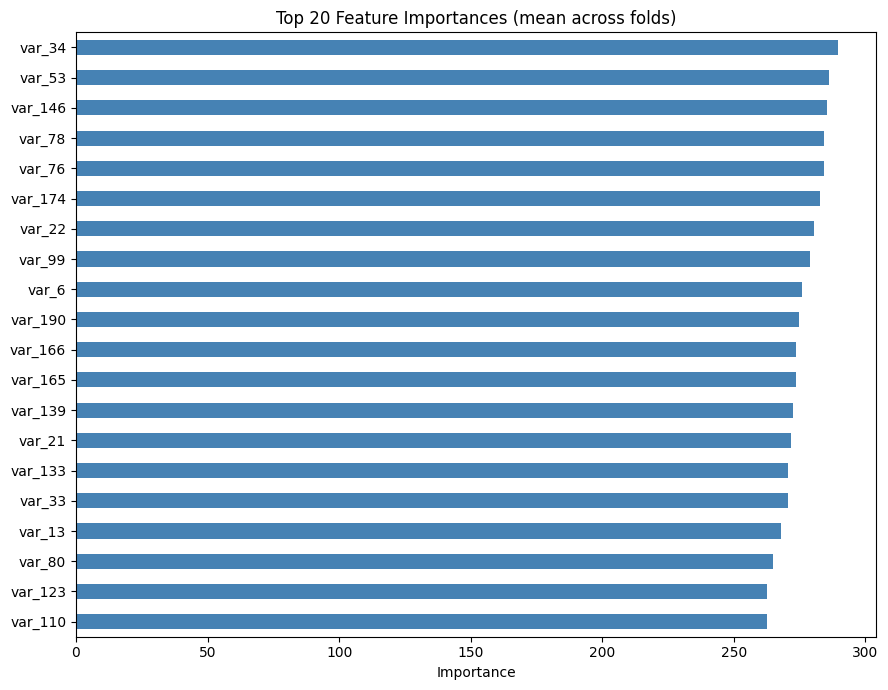

In [41]:
# Average feature importances across all folds
importance_df = pd.DataFrame(index=lgbm_features)
for i, m in enumerate(models):
    importance_df[f'fold_{i+1}'] = m.feature_importances_

importance_df['mean'] = importance_df.mean(axis=1)
top20 = importance_df['mean'].sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 7))
top20.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 Feature Importances (mean across folds)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

---
## 11. Submissions

### 11.1 LightGBM Submission

In [42]:

submission_lgbm_tuned = pd.DataFrame({
    'ID_code': df_test['ID_code'],
    'target':  test_preds_tuned
})
submission_lgbm_tuned.to_csv('submission_lightgbm_tuned.csv', index=False)
print('Saved: submission_lightgbm_tuned.csv')
submission_lgbm_tuned.head()

Saved: submission_lightgbm_tuned.csv


,ID_code,target
0,test_0,0.0757
1,test_1,0.2219
2,test_2,0.2715
3,test_3,0.2090
4,test_4,0.0642


### 11.2 Results Summary

| Model | Local CV AUC | Kaggle Public AUC | Kaggle Private AUC |
|-------|-------------|-------------------|-------------------|
| Gaussian Naive Bayes v1 (row-wise features) | 0.8836 | 0.88392 | 0.88244 |
| Gaussian Naive Bayes v2 (+ value-count features) | 0.8587 | 0.85860 | 0.85881 |
| Gaussian Naive Bayes v3 (+ QuantileTransformer) | 0.8836 | 0.88579 | 0.88367 |
| LightGBM (default params, 5-fold OOF) | 0.9062 | — | — |
| LightGBM (Optuna-tuned, 5-fold OOF) | 0.9073 | **0.91034** | **0.90730** |


Target:

Public AUC ≥ 0.899 (top 10%) for Part 1 — gap: ~0.013

Public AUC ≥ 0.921 (top 60) for Part 2 — gap: ~0.011

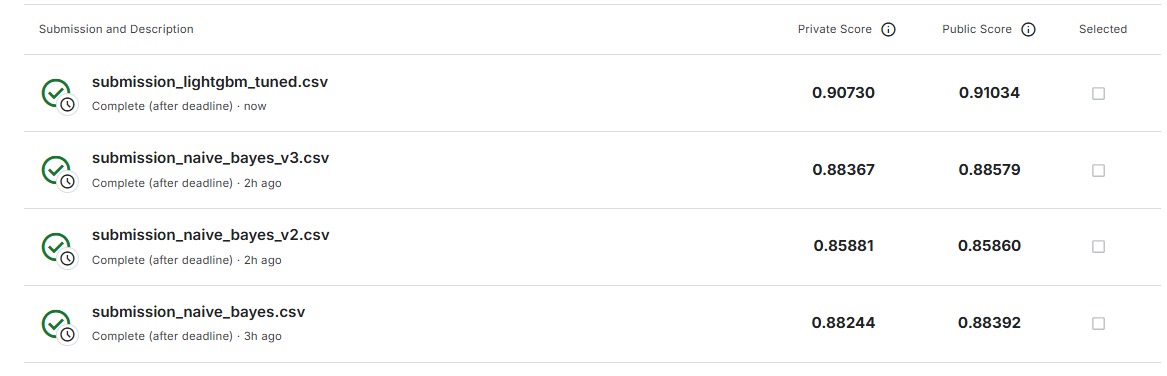


---
## What worked, what didn't, and next steps

- **Summary of results:** GaussianNB (row-wise features) AUC ≈ 0.8836; NB + value-counts (v2) degraded; NB + QuantileTransformer (v3) improved to ≈ 0.8858. LightGBM (Optuna-tuned) OOF AUC ≈ 0.9073 (public ≈ 0.9103).

- **What worked:**
    - Simple row-wise aggregates (mean, std, min/max, unique) consistently helped both models.
    - Detecting real vs synthetic test rows and computing value-count features on real data improved robustness for tree models.
    - QuantileTransformer before GaussianNB corrected non-Gaussianity and improved NB performance.
    - Optuna tuning + LightGBM produced the best overall AUC.

- **What did not work / caveats:**
    - Adding raw value-count features to NB without transforming produced unstable / overconfident predictions (v2).
    - Naive Bayes is limited by conditional independence and feature distributions; gains plateau without transformations or richer features.

- **If more time:**
    - Blend/stack NB and LightGBM (calibrate NB probs before ensembling).
    - Engineer pairwise/interaction features and simple target encodings for trees.
    - Run larger Optuna budgets, stronger regularisation search, and adversarial validation to reduce synthetic-test leakage.
